In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [40]:
file_path = "/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset loaded successfully!
Shape of dataset: (15000, 19)

First 5 rows:


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low



Column names:
['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket', 'diabetes_risk']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet

In [42]:
print("\nMissing values:")
print(df.isnull().sum())



print("\nNumber of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)





Missing values:
patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

Number of duplicate rows: 0
Shape after removing duplicates: (15000, 19)


In [43]:
print("\nUnique values in each column:")
for column in df.columns:
    print("\n", column)
    print(df[column].unique()[:20])


Unique values in each column:

 patient_id
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

 age
[47 53 41 57 58 42 44 51 38 22 26 46 49 37 40 63 45 39 55 48]

 gender
['Female' 'Male' 'Other']

 city
['Mumbai' 'Thane' 'Bengaluru' 'Hyderabad' 'Delhi' 'Kolkata' 'Ahmedabad'
 'Pune' 'Chennai' 'Kanpur' 'Bhopal' 'Visakhapatnam' 'Patna' 'Jaipur'
 'Surat' 'Nagpur' 'Indore' 'Lucknow']

 bmi
[26.5 20.5 31.3 22.8 16.7 22.  22.5 19.5 20.3 24.1 21.5 23.3 19.3 15.
 21.4 19.6 21.7 26.8 20.4 18.2]

 family_history_diabetes
['Yes' 'No']

 physical_activity_level
['Sedentary' 'Moderate' 'Active']

 diet_type
['Vegetarian' 'Non-Vegetarian' 'Pescatarian' 'Vegan']

 smoking_status
['Never' 'Current' nan 'Former']

 alcohol_consumption
['Never' 'Regular' 'Occasional' nan]

 hours_sleep_per_night
[ 9.   7.   6.5  6.9  6.   4.8  6.2 10.   8.9  8.   7.6  7.9  6.3  5.3
  8.1  6.6  7.7  8.4  8.5  7.5]

 stress_level
[ 8  6  7  5 10  2  4  9  1  3]

 fasting_blood_sugar
[178 152 168 155 188 148 19

In [45]:
target_column = df.columns[-1]

print("\nTarget column selected:", target_column)

# Separate input and output
X = df.drop(columns=[target_column])
y = df[target_column]



Target column selected: diabetes_risk


In [51]:
label_encoder = LabelEncoder()

if y.dtype == "object" or str(y.dtype).startswith("category"):
    y = label_encoder.fit_transform(y.astype(str))

print("\nTarget values:")
print(np.unique(y))


Target values:
[0 1 2]


In [52]:
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X = X.astype(float)


Categorical columns:
['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']

Numerical columns:
['patient_id', 'age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']


In [53]:
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("\nMissing values after preprocessing:")
print(X.isnull().sum().sum())



Missing values after preprocessing:
0


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)



Training data shape: (12000, 41)
Testing data shape: (3000, 41)


In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


NAIVE BAYES
Naive Bayes Accuracy: 74.33 %

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.66      0.68       450
           1       0.89      0.80      0.84      1800
           2       0.52      0.66      0.58       750

    accuracy                           0.74      3000
   macro avg       0.70      0.71      0.70      3000
weighted avg       0.77      0.74      0.75      3000



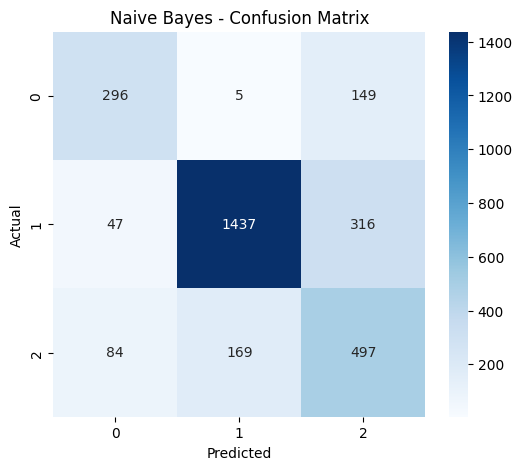

In [62]:
print("\n" + "="*60)
print("NAIVE BAYES")
print("="*60)

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:",
      round(nb_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



DECISION TREE
Decision Tree Accuracy: 76.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.62      0.70       450
           1       0.85      0.89      0.87      1800
           2       0.54      0.55      0.55       750

    accuracy                           0.77      3000
   macro avg       0.73      0.69      0.71      3000
weighted avg       0.76      0.77      0.76      3000



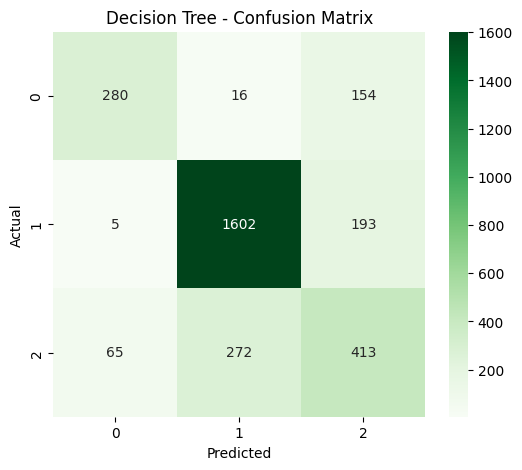

In [63]:
print("\n" + "="*60)
print("DECISION TREE")
print("="*60)

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


K-NEAREST NEIGHBORS
KNN Accuracy: 68.37 %

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.48      0.55       450
           1       0.74      0.91      0.81      1800
           2       0.45      0.27      0.34       750

    accuracy                           0.68      3000
   macro avg       0.61      0.55      0.57      3000
weighted avg       0.65      0.68      0.66      3000



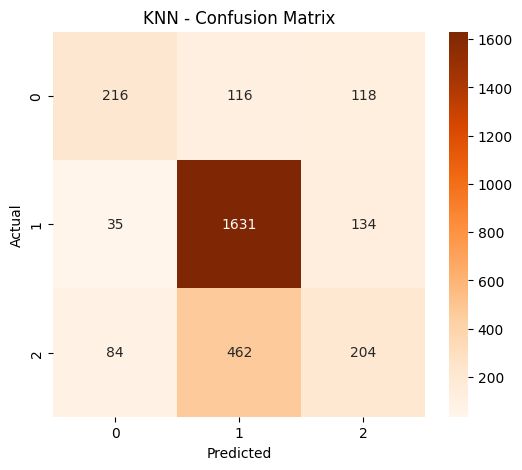

In [65]:
print("\n" + "="*60)
print("K-NEAREST NEIGHBORS")
print("="*60)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:",
      round(knn_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [67]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        nb_accuracy,
        dt_accuracy,
        knn_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

print(results[["Model", "Accuracy (%)"]].to_string(index=False))


MODEL COMPARISON
        Model  Accuracy (%)
  Naive Bayes     74.333333
Decision Tree     76.500000
          KNN     68.366667


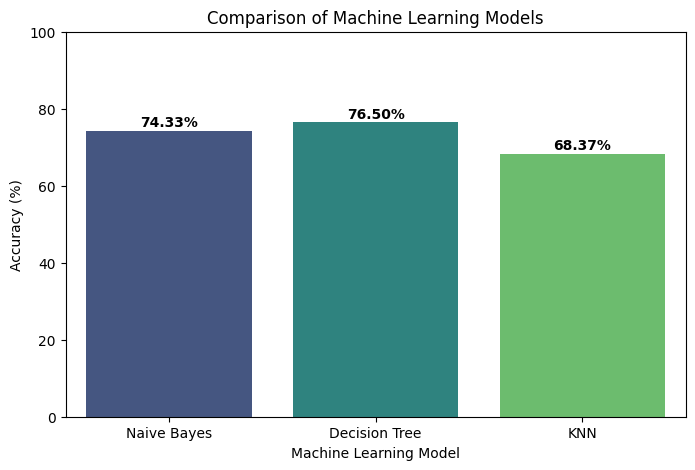

In [68]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(results["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

In [69]:
best_model = results.loc[
    results["Accuracy (%)"].idxmax()
]

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)

print("Best Model:", best_model["Model"])
print(
    "Best Accuracy:",
    round(best_model["Accuracy (%)"], 2),
    "%"
)




BEST MODEL
Best Model: Decision Tree
Best Accuracy: 76.5 %
